# Causal Inference in Practice: Does Service Recovery Outreach Actually Improve Guest Satisfaction?

**A hands-on hotel-management project built from Chapter 5 ("Propensity Score") of *Causal Inference in Python: Applying Causal Inference in the Tech Industry***

## The business problem

You work as a data scientist for a hotel chain. When a guest has a rough moment
during their stay — a noisy room, a billing mix-up, a late housekeeping request —
the **Guest Relations** team can step in with a **service recovery call**: a manager
personally reaches out, apologizes, and often comps something (a free breakfast, a
room upgrade, a late checkout) to make things right before the guest checks out.

Leadership wants to know: **does a service recovery call actually cause higher
post-stay satisfaction**, or are the calls simply going to the guests who were
already going to have a good (or bad) outcome regardless?

This is *structurally identical* to the "manager training" and "customer outreach"
problems from Chapter 5: a well-intentioned intervention that is **not randomly
assigned**. Guest Relations naturally prioritizes calling guests who look
**unhappy right now** (multiple complaints logged, low predicted satisfaction) —
so a naive before/after or treated-vs-control comparison will be badly biased, and
in fact will likely make the recovery calls look *harmful*, since the guests who get
them were already trending toward a worse experience.

## What you will practice in this notebook

Using the propensity-score toolkit from Chapter 5, applied end-to-end to a fresh,
realistic hotel-industry dataset:

1. **Naive comparison** — see the bias for yourself
2. **Regression adjustment** — the Chapter 4 benchmark
3. **Propensity score estimation** — logistic regression modeling of the treatment
4. **Overlap / positivity diagnostics** — the check most people skip
5. **Propensity score matching** — nearest-neighbor matching on the propensity score
6. **Inverse Propensity Weighting (IPW)**, with **stabilized weights**
7. **Bootstrap confidence intervals** for IPW
8. **Doubly Robust (DR) estimation** — combining regression + IPW
9. A **bias–variance / positivity-violation demo** — why IPW can fail
10. A **bonus extension**: Generalized Propensity Score (GPS) for a **continuous
    treatment** — how much **dynamic-pricing discount** a guest is offered, and its
    effect on how many **extra nights** they end up booking — this is a near-exact
    match to the bank interest-rate example in the book

Because the dataset is *simulated*, we know the **true causal effect** ahead of time.
That means at the end of the notebook you can literally check each estimator's
answer against the ground truth — the best way to build intuition for when each
method works and when it doesn't.

> **Note:** There's no bundled hotel dataset with the book, so this notebook
> generates a comparable, fully-documented synthetic dataset instead. Every
> simulation step is commented so you can see exactly how the confounding is built
> in — and you can swap in your own property-management-system (PMS) data later by
> keeping the same treatment/outcome/confounder roles.


## 0. Setup

Same stack the book uses: `pandas`/`numpy` for data, `statsmodels` for OLS/logit
with nice formulas, `scikit-learn` for the ML-flavored propensity/outcome models,
`patsy` for building design matrices from formulas, and `joblib` for a parallel
bootstrap.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from patsy import dmatrix
from scipy.stats import norm
from joblib import Parallel, delayed
from functools import partial

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
np.random.seed(42)


## 1. Build the dataset

We simulate 8,000 hotel stays. This is the only part of the notebook where we
"cheat" (we get to see the true causal effect) — that's intentional, it's what lets
us grade each estimator later.

**Confounders (X):**
- `loyalty_tier`: `standard` / `silver` / `gold` membership tier
- `past_stays`: number of previous stays at this hotel chain
- `nights_booked`: length of the original booking
- `complaints_logged`: number of service issues logged during this stay
- `pre_call_expected_satisfaction`: a baseline satisfaction expectation, formed from
  check-in sentiment, room type, and early-stay signals — think of it as a
  "predicted satisfaction if nothing else happens" score

**Treatment (T):** `recovery_call` — did Guest Relations proactively call this
guest during their stay?

**Outcome (Y):** `satisfaction_score` — the post-stay satisfaction survey score
(standardized)

**The confounding we bake in:** Guest Relations is *more* likely to call guests who
look unhappy — i.e., guests with **more `complaints_logged`** and **lower
`pre_call_expected_satisfaction`**. But those same guests also tend to end up with
**lower final `satisfaction_score`** *regardless* of the call, simply because their
stay started rough. This is exactly the confounding pattern from the book: the
intervention is targeted at the people who need it most, which biases a naive
comparison **downward**.


In [2]:
n = 8000

past_stays = np.random.poisson(3, size=n)
loyalty_tier = np.where(
    past_stays >= 8, "gold", np.where(past_stays >= 3, "silver", "standard")
)
loyalty_weight = pd.Series(loyalty_tier).map({"standard": 0.0, "silver": 0.35, "gold": 0.8}).values

nights_booked = np.random.poisson(2.5, size=n) + 1
complaints_logged = np.random.poisson(0.6 + 0.15 * nights_booked, size=n)

pre_call_expected_satisfaction = np.random.normal(
    0.6 - 0.25 * np.log1p(complaints_logged) + 0.15 * loyalty_weight, 1.0
)

# --- treatment assignment mechanism (NOT random!) ---
# Guest Relations prioritizes calling guests who already look unhappy
unhappiness_score = (
    -1.1 * pre_call_expected_satisfaction + 0.35 * complaints_logged - 0.02 * past_stays
)
true_propensity = 1 / (1 + np.exp(-(0.2 + 0.9 * unhappiness_score)))
recovery_call = np.random.binomial(1, true_propensity)

# --- true causal effect of the recovery call on post-stay satisfaction ---
TRUE_ATE = 0.55
noise = np.random.normal(0, 0.6, n)
satisfaction_score = (
    pre_call_expected_satisfaction
    + TRUE_ATE * recovery_call
    + 0.12 * loyalty_weight
    - 0.05 * complaints_logged
    + noise
)

df = pd.DataFrame(
    dict(
        stay_id=np.arange(n),
        loyalty_tier=loyalty_tier,
        past_stays=past_stays,
        nights_booked=nights_booked,
        complaints_logged=complaints_logged,
        pre_call_expected_satisfaction=pre_call_expected_satisfaction,
        recovery_call=recovery_call,
        satisfaction_score=satisfaction_score,
    )
)

print(f"True ATE (by construction): {TRUE_ATE}")
print(f"Share of stays that received a service recovery call: {df['recovery_call'].mean():.1%}")
df.head()


True ATE (by construction): 0.55
Share of stays that received a service recovery call: 50.9%


,stay_id,loyalty_tier,past_stays,nights_booked,complaints_logged,pre_call_expected_satisfaction,recovery_call,satisfaction_score
0,0,silver,4,2,1,-0.419863,0,-0.617210
1,1,standard,1,2,0,0.013572,0,-0.303806
2,2,silver,3,9,2,0.928423,0,0.851886
3,3,silver,3,4,2,1.579840,1,1.878910
4,4,standard,2,4,2,0.624413,1,0.703978


## 2. The naive comparison (and why it's wrong)

Just like the book's opening move in Chapter 5, let's first compute the simplest
possible estimate: the raw difference in mean `satisfaction_score` between stays
that got a recovery call and those that didn't.


In [3]:
naive_diff = (
    df.query("recovery_call == 1")["satisfaction_score"].mean()
    - df.query("recovery_call == 0")["satisfaction_score"].mean()
)
print(f"Naive difference in means: {naive_diff:.4f}")
print(f"True ATE:                 {TRUE_ATE:.4f}")


Naive difference in means: -0.2915
True ATE:                 0.5500


The naive estimate massively understates (or even flips the sign of) the true
benefit of a recovery call. This is exactly the trap the book warns about: the
"treatment" was aimed at guests who were already heading toward a worse outcome, so
comparing them directly to guests who never had a problem makes the call look
useless or even harmful — when in fact it's helping.


## 3. Benchmark: regression adjustment

Before reaching for propensity scores, the book always sets a regression benchmark
first ("it's always a good idea to have some benchmark you trust to compare to").
We regress the outcome on treatment **and** all observed confounders.


In [4]:
reg_model = smf.ols(
    "satisfaction_score ~ recovery_call + pre_call_expected_satisfaction "
    "+ complaints_logged + past_stays + nights_booked + C(loyalty_tier)",
    data=df,
).fit()

reg_ate = reg_model.params["recovery_call"]
reg_ci = reg_model.conf_int().loc["recovery_call"].values

print(f"Regression-adjusted ATE: {reg_ate:.4f}")
print(f"95% CI:                  [{reg_ci[0]:.4f}, {reg_ci[1]:.4f}]")


Regression-adjusted ATE: 0.5712
95% CI:                  [0.5416, 0.6008]


Much closer to the truth. Regression removed most of the bias by explicitly
controlling for `pre_call_expected_satisfaction`, `complaints_logged`, `past_stays`,
`nights_booked`, and `loyalty_tier`. Now let's get the same kind of answer using the
propensity-score machinery from the chapter — and see that the two approaches agree.


## 4. The propensity score

The propensity score $e(x) = P(T=1 \mid X)$ is the probability that a guest with
covariates $X$ receives a recovery call. The key theoretical result from the chapter
is that you don't need to condition on the (possibly high-dimensional) $X$
directly — conditioning on the **single number** $e(x)$ is enough to block the
backdoor path from $X$ into $T$:

$$(Y_1, Y_0) \perp T \mid X \quad \Longrightarrow \quad (Y_1, Y_0) \perp T \mid e(X)$$

Intuitively: two guests with the *same* probability of getting a call, one of whom
got called and one who didn't, only differ by chance — so they're a valid
apples-to-apples comparison.

We estimate $\hat e(x)$ with a logistic regression, exactly as the book does.


In [5]:
ps_model = smf.logit(
    "recovery_call ~ pre_call_expected_satisfaction + complaints_logged "
    "+ past_stays + nights_booked + C(loyalty_tier)",
    data=df,
).fit(disp=0)

df["propensity_score"] = ps_model.predict(df)
df[["recovery_call", "satisfaction_score", "propensity_score"]].head()


,recovery_call,satisfaction_score,propensity_score
0,0,-0.617210,0.715555
1,0,-0.303806,0.546188
2,0,0.851886,0.463019
3,1,1.878910,0.318362
4,1,0.703978,0.553597


## 5. Positivity / overlap diagnostic (don't skip this!)

The book stresses that IPW only works if there's **overlap**: for every region of
the covariate space, we need *both* called and non-called guests. If Guest Relations
calls literally every guest who complains and literally no one else, there's no data
left to estimate what would have happened to a complaining guest *without* a call —
a **positivity violation**.

Let's plot $\hat e(x)$ split by actual treatment status.


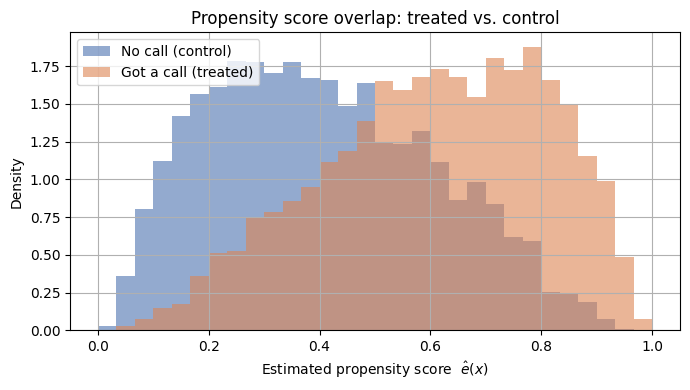

count    8000.000000
mean        0.508750
std         0.224688
min         0.028487
25%         0.330323
50%         0.511115
75%         0.689994
max         0.991878
Name: propensity_score, dtype: float64

Share of scores below 0.02 or above 0.98: 0.06%


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 31)
ax.hist(df.query("recovery_call == 0")["propensity_score"], bins=bins, alpha=0.6,
        label="No call (control)", color="#4c72b0", density=True)
ax.hist(df.query("recovery_call == 1")["propensity_score"], bins=bins, alpha=0.6,
        label="Got a call (treated)", color="#dd8452", density=True)
ax.set_xlabel("Estimated propensity score  $\\hat e(x)$")
ax.set_ylabel("Density")
ax.set_title("Propensity score overlap: treated vs. control")
ax.legend()
plt.tight_layout()
plt.show()

print(df["propensity_score"].describe())
print("\nShare of scores below 0.02 or above 0.98:",
      f"{((df['propensity_score'] < 0.02) | (df['propensity_score'] > 0.98)).mean():.2%}")


Good news: the two distributions overlap substantially (called guests skew
higher, as expected, but there's no region owned exclusively by one group, and
almost no scores sit near the 0/1 extremes). This tells us IPW should behave well
here — a very different story from the positivity-violation example we'll build in
Section 9.


## 6. Propensity score matching

As a first way to *use* the propensity score, we match each called guest to their
nearest-neighbor (by $\hat e(x)$) among non-called guests, and vice versa, then
average the outcome differences within matched pairs. This is the $K=1$ KNN approach
the book walks through.

> The book itself is lukewarm on this estimator (biased, hard to get standard errors
> for, and inefficient in high dimensions) — we include it here mainly so you can see
> *why* IPW tends to be preferred in practice.


In [7]:
T, X_ps, Y = "recovery_call", "propensity_score", "satisfaction_score"

treated = df.query(f"{T} == 1")
control = df.query(f"{T} == 0")

# match every control unit to its nearest treated unit (to impute Y1 for controls)
knn_treated = KNeighborsRegressor(n_neighbors=1).fit(treated[[X_ps]], treated[Y])
# match every treated unit to its nearest control unit (to impute Y0 for treated)
knn_control = KNeighborsRegressor(n_neighbors=1).fit(control[[X_ps]], control[Y])

matched = pd.concat([
    treated.assign(match=knn_control.predict(treated[[X_ps]])),
    control.assign(match=knn_treated.predict(control[[X_ps]])),
])

matching_ate = np.mean(
    (matched[Y] - matched["match"]) * matched[T]
    + (matched["match"] - matched[Y]) * (1 - matched[T])
)
print(f"Propensity score matching ATE: {matching_ate:.4f}")


Propensity score matching ATE: 0.5548


## 7. Inverse Propensity Weighting (IPW)

IPW reweights each stay by the inverse probability of the treatment it actually
received, creating a *pseudo-population* in which treatment looks as good as
randomly assigned:

$$ATE = E\!\left[\frac{\mathbb{1}(T=1)\,Y}{\hat e(X)}\right] - E\!\left[\frac{\mathbb{1}(T=0)\,Y}{1-\hat e(X)}\right]$$

which simplifies (as in the book) to the single-expression form:

$$ATE = E\!\left[Y \cdot \frac{T - \hat e(X)}{\hat e(X)(1-\hat e(X))}\right]$$


In [8]:
weight_treated = 1 / df.query(f"{T} == 1")[X_ps]
weight_control = 1 / (1 - df.query(f"{T} == 0")[X_ps])

y1_hat = (df.query(f"{T} == 1")[Y] * weight_treated).sum() / len(df)
y0_hat = (df.query(f"{T} == 0")[Y] * weight_control).sum() / len(df)

ipw_ate = y1_hat - y0_hat
print(f"E[Y1] = {y1_hat:.4f}")
print(f"E[Y0] = {y0_hat:.4f}")
print(f"IPW ATE = {ipw_ate:.4f}")

# sanity check: the single-expression formula should give the exact same number
ipw_ate_check = np.mean(
    df[Y] * (df[T] - df[X_ps]) / (df[X_ps] * (1 - df[X_ps]))
)
print(f"IPW ATE (single-formula check) = {ipw_ate_check:.4f}")


E[Y1] = 1.0160
E[Y0] = 0.4578
IPW ATE = 0.5581
IPW ATE (single-formula check) = 0.5581


### Stabilized weights

Raw IPW weights can blow up when $\hat e(x)$ is close to 0 or 1. **Stabilizing** the
weights by the marginal probability of treatment, $P(T=t)$, keeps the *effective*
sample size close to the original sample size while giving the exact same point
estimate.


In [9]:
p_of_t = df[T].mean()
t1, t0 = df.query(f"{T} == 1"), df.query(f"{T} == 0")

w_t_stable = p_of_t / t1[X_ps]
w_nt_stable = (1 - p_of_t) / (1 - t0[X_ps])

print("Original sample size:              ", len(df))
print("Treated pseudo-population size:    ", round(w_t_stable.sum(), 1), " (actual treated n =", len(t1), ")")
print("Untreated pseudo-population size:  ", round(w_nt_stable.sum(), 1), " (actual control n =", len(t0), ")")

ipw_ate_stable = (
    (t1[Y] * w_t_stable).sum() / len(t1) - (t0[Y] * w_nt_stable).sum() / len(t0)
)
print(f"\nStabilized IPW ATE: {ipw_ate_stable:.4f}  (matches the unstabilized estimate, as expected)")


Original sample size:               8000
Treated pseudo-population size:     4079.9  (actual treated n = 4070 )
Untreated pseudo-population size:   3903.0  (actual control n = 3930 )

Stabilized IPW ATE: 0.5581  (matches the unstabilized estimate, as expected)


## 8. Bootstrap confidence interval for IPW

Unlike OLS, IPW doesn't have a clean closed-form standard error, so — following the
book — we wrap the whole estimation procedure (propensity model + weighting) into a
single function and bootstrap it.


In [10]:
def est_ate_with_ps(data, ps_formula, T, Y):
    # Fit a propensity model with sklearn's LogisticRegression and return the IPW ATE.
    Xmat = dmatrix(ps_formula, data)
    ps_model = LogisticRegression(max_iter=1000, C=1e6).fit(Xmat, data[T])
    ps = ps_model.predict_proba(Xmat)[:, 1]
    return np.mean(data[Y] * (data[T] - ps) / (ps * (1 - ps)))


def bootstrap(data, est_fn, rounds=300, seed=0, pcts=(2.5, 97.5), n_jobs=4):
    np.random.seed(seed)
    stats = Parallel(n_jobs=n_jobs)(
        delayed(est_fn)(data.sample(frac=1, replace=True)) for _ in range(rounds)
    )
    point = est_fn(data)
    return point, np.percentile(stats, pcts)


ps_formula = "pre_call_expected_satisfaction + complaints_logged + past_stays + nights_booked + C(loyalty_tier)"
ipw_fn = partial(est_ate_with_ps, ps_formula=ps_formula, T=T, Y=Y)

ipw_point, ipw_ci = bootstrap(df, ipw_fn, rounds=300)
print(f"IPW ATE: {ipw_point:.4f}")
print(f"95% CI:  [{ipw_ci[0]:.4f}, {ipw_ci[1]:.4f}]")


IPW ATE: 0.5580
95% CI:  [0.5113, 0.6012]


## 9. Doubly Robust (DR) estimation

DR combines an **outcome model** $\hat m(X)$ (like regression) with a **propensity
model** $\hat e(X)$ (like logistic regression) so that the estimate is consistent if
*either one* of the two models is correctly specified — you get two chances to be
right instead of one:

$$\hat\mu^{DR}_t(\hat m, \hat e) = \frac{1}{N}\sum \hat m(X) + \frac{1}{N}\sum\left[\frac{T}{\hat e(x)}\big(Y - \hat m(X)\big)\right]$$

$$ATE = \hat\mu^{DR}_1(\hat m, \hat e) - \hat\mu^{DR}_0(\hat m, \hat e)$$


In [11]:
def doubly_robust(data, formula, T, Y):
    Xmat = dmatrix(formula, data)

    ps_model = LogisticRegression(max_iter=1000, C=1e6).fit(Xmat, data[T])
    ps = ps_model.predict_proba(Xmat)[:, 1]

    m0 = LinearRegression().fit(Xmat[data[T] == 0], data[Y][data[T] == 0])
    m1 = LinearRegression().fit(Xmat[data[T] == 1], data[Y][data[T] == 1])
    m0_hat, m1_hat = m0.predict(Xmat), m1.predict(Xmat)

    mu1 = np.mean(data[T] * (data[Y] - m1_hat) / ps + m1_hat)
    mu0 = np.mean((1 - data[T]) * (data[Y] - m0_hat) / (1 - ps) + m0_hat)
    return mu1 - mu0


dr_fn = partial(doubly_robust, formula=ps_formula, T=T, Y=Y)
dr_point, dr_ci = bootstrap(df, dr_fn, rounds=300)

print(f"Doubly robust ATE: {dr_point:.4f}")
print(f"95% CI:            [{dr_ci[0]:.4f}, {dr_ci[1]:.4f}]")


Doubly robust ATE: 0.5671
95% CI:            [0.5349, 0.5985]


## 10. Scoreboard: comparing every estimator against the truth

Since this is simulated data, we get to check our homework.


In [12]:
results = pd.DataFrame(
    [
        ("Naive difference in means", naive_diff, np.nan, np.nan),
        ("Regression adjustment", reg_ate, reg_ci[0], reg_ci[1]),
        ("Propensity score matching (K=1)", matching_ate, np.nan, np.nan),
        ("IPW (bootstrap CI)", ipw_point, ipw_ci[0], ipw_ci[1]),
        ("Doubly robust (bootstrap CI)", dr_point, dr_ci[0], dr_ci[1]),
    ],
    columns=["Method", "ATE estimate", "CI low", "CI high"],
)
results["Error vs. true ATE"] = results["ATE estimate"] - TRUE_ATE
results = results.round(4)
results


,Method,ATE estimate,CI low,CI high,Error vs. true ATE
0,Naive difference in means,-0.2915,NaN,NaN,-0.8415
1,Regression adjustment,0.5712,0.5416,0.6008,0.0212
2,Propensity score matching (K=1),0.5548,NaN,NaN,0.0048
3,IPW (bootstrap CI),0.5580,0.5113,0.6012,0.0080
4,Doubly robust (bootstrap CI),0.5671,0.5349,0.5985,0.0171


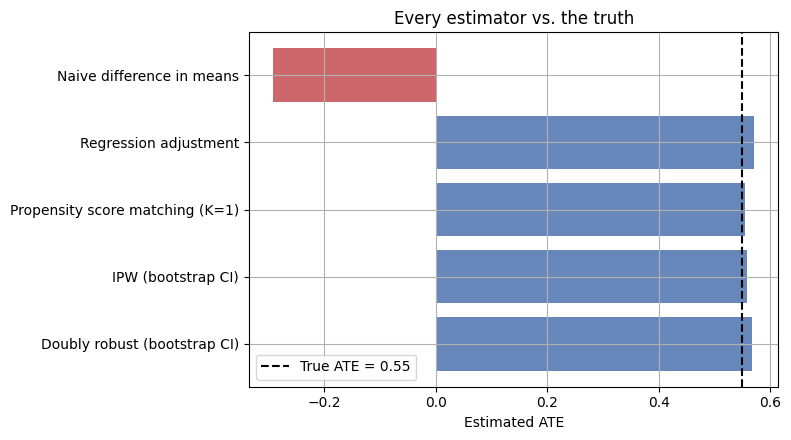

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(results))
colors = ["#c44e52" if m == "Naive difference in means" else "#4c72b0" for m in results["Method"]]
ax.barh(y_pos, results["ATE estimate"], color=colors, alpha=0.85)
ax.axvline(TRUE_ATE, color="black", linestyle="--", linewidth=1.5, label=f"True ATE = {TRUE_ATE}")
ax.set_yticks(y_pos)
ax.set_yticklabels(results["Method"])
ax.set_xlabel("Estimated ATE")
ax.set_title("Every estimator vs. the truth")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Every bias-adjusted method lands close to the true effect of `0.55`; only the
naive comparison is way off. This is the core lesson of the chapter: **regression,
matching, IPW, and DR are all different ways of doing the same underlying job** —
making called and non-called guests comparable by adjusting for the treatment
assignment mechanism.


## 11. When IPW breaks: a positivity-violation stress test

The book is careful to point out that IPW is *not* magic — if the propensity model
is "too good" (i.e., it near-perfectly separates called from non-called guests), the
weights explode and the estimator becomes unusable, even though regression, which
*extrapolates*, might still get close to the right answer.

Let's build a small toy dataset with almost no overlap — imagine `x` is a
**complaint-severity score** that almost deterministically decides whether Guest
Relations calls the guest — exactly like the book's Section on "Positivity", and
watch IPW struggle while regression (helped by a smooth, correctly-specified
functional form) survives.


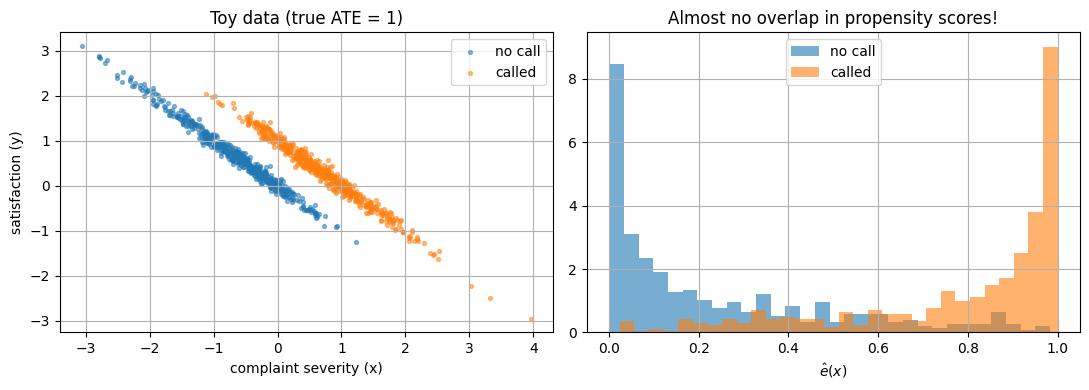

In [14]:
np.random.seed(1)
n_toy = 1000
severity = np.random.normal(0, 1, n_toy)          # complaint severity score
called = (np.random.normal(severity, 0.5, n_toy) > 0).astype(int)  # call strongly tied to severity

# without a call, satisfaction gets worse the more severe the complaint
sat0_toy = -severity
sat1_toy = sat0_toy + 1  # true ATE = 1 (a call always helps by +1)
sat_toy = np.random.normal((1 - called) * sat0_toy + called * sat1_toy, 0.1)

df_toy = pd.DataFrame(dict(x=severity, t=called, y=sat_toy))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df_toy.query("t==0")["x"], df_toy.query("t==0")["y"], s=8, label="no call", alpha=0.5)
axes[0].scatter(df_toy.query("t==1")["x"], df_toy.query("t==1")["y"], s=8, label="called", alpha=0.5)
axes[0].set_title("Toy data (true ATE = 1)")
axes[0].set_xlabel("complaint severity (x)"); axes[0].set_ylabel("satisfaction (y)"); axes[0].legend()

ps_toy = smf.logit("t ~ x", data=df_toy).fit(disp=0).predict(df_toy)
axes[1].hist(ps_toy[df_toy.t == 0], bins=30, alpha=0.6, label="no call", density=True)
axes[1].hist(ps_toy[df_toy.t == 1], bins=30, alpha=0.6, label="called", density=True)
axes[1].set_title("Almost no overlap in propensity scores!")
axes[1].set_xlabel("$\\hat e(x)$"); axes[1].legend()
plt.tight_layout()
plt.show()


In [15]:
# IPW on the near-violation data
ipw_toy_point, ipw_toy_ci = bootstrap(df_toy, partial(est_ate_with_ps, ps_formula="x", T="t", Y="y"), rounds=200)
print(f"IPW ATE on toy data:        {ipw_toy_point:.4f}   95% CI [{ipw_toy_ci[0]:.4f}, {ipw_toy_ci[1]:.4f}]  (true ATE = 1)")

# Regression on the same data
reg_toy = smf.ols("y ~ x + t", data=df_toy).fit()
print(f"Regression ATE on toy data: {reg_toy.params['t']:.4f}")


IPW ATE on toy data:        0.6527   95% CI [0.4692, 0.8361]  (true ATE = 1)
Regression ATE on toy data: 1.0083


IPW's confidence interval is wide **and often doesn't even contain the true value
of 1** — it's not just imprecise, it's biased, because there simply isn't enough
data in some regions to reconstruct the missing counterfactual (almost no guests
with severe complaints go uncalled, and almost no guests with mild complaints get
called). Regression, by contrast, smoothly extrapolates across `x` and recovers the
true effect almost exactly. This is the practical version of the book's "Design- vs.
Model-Based Identification" discussion: IPW makes no assumption on the shape of
$E[Y \mid X]$, so when the design (positivity) fails, it has nothing to fall back
on. This is also *why* doubly robust estimation is so attractive — it gives you a
second chance if positivity is shaky but your outcome model is reasonable.


## 12. Bonus: continuous treatment with the Generalized Propensity Score

So far, `recovery_call` has been binary. But hotels also run **continuous**
interventions — the clearest example is **dynamic pricing**: a revenue-management
algorithm offers each guest a **discount %** on an extended stay, and you want to
know its causal effect on how many **extra nights** the guest books. This mirrors
the book's bank interest-rate example almost exactly (interest rate → loan duration
becomes discount % → extra nights booked).

The problem: $P(T=t \mid X) = 0$ for any continuous $t$, so we can't use a plain
propensity score. Instead we model the **conditional density** $f(T \mid X)$,
assuming (as the book does) that $T \mid X \sim \mathcal N(\mu(X), \sigma^2)$, and
reweight by the inverse of that density (stabilized by the marginal density
$f(T)$) — the **Generalized Propensity Score (GPS)**.


In [16]:
np.random.seed(7)  # local seed so this section is reproducible on its own

n_c = 10000
demand_forecast_score = np.random.normal(0, 1, n_c)  # e.g., a revenue-mgmt demand model
guest_loyalty_score = np.random.normal(0, 1, n_c)     # e.g., a loyalty/LTV model score

# discount % assigned based on the two model scores + noise -> continuous, confounded treatment
# (we deliberately do NOT clip the treatment: clipping truncates the tails and breaks
#  the Normal conditional-density assumption the GPS below relies on)
discount_pct = 10 + 1.0 * demand_forecast_score - 0.6 * guest_loyalty_score + np.random.normal(0, 3.0, n_c)

TRUE_SLOPE = 0.5  # true causal effect: +1pt discount -> +0.5 extra nights booked
extra_nights = (
    TRUE_SLOPE * discount_pct + 1.8 * demand_forecast_score - 1.3 * guest_loyalty_score
    + np.random.normal(0, 2, n_c)
)

df_cont = pd.DataFrame(dict(
    demand_forecast_score=demand_forecast_score,
    guest_loyalty_score=guest_loyalty_score,
    discount_pct=discount_pct,
    extra_nights=extra_nights,
))

naive_cont = smf.ols("extra_nights ~ discount_pct", data=df_cont).fit()
print("Naive (unadjusted) slope:", round(naive_cont.params["discount_pct"], 4))
print("True slope:              ", TRUE_SLOPE)


Naive (unadjusted) slope: 0.7444
True slope:               0.5


In [17]:
# Step 1: model the conditional mean of the treatment given confounders
treatment_model = smf.ols("discount_pct ~ demand_forecast_score + guest_loyalty_score", data=df_cont).fit()
mu_i = treatment_model.fittedvalues
sigma = np.std(treatment_model.resid)

# Step 2: evaluate the conditional density f(T=t | X) at the observed treatment (the GPS)
gps = norm(loc=mu_i, scale=sigma).pdf(df_cont["discount_pct"])

# Step 3: stabilize with the marginal density f(T=t)
marginal_density = norm(
    loc=df_cont["discount_pct"].mean(), scale=np.std(df_cont["discount_pct"])
).pdf(df_cont["discount_pct"])

gps_weight_stable = marginal_density / gps

print("Original sample size:                  ", len(df_cont))
print("Effective sample size (stabilized GPS): ", round(gps_weight_stable.sum(), 1))

# Step 4: weighted regression to recover the causal slope
gps_model = smf.wls("extra_nights ~ discount_pct", data=df_cont, weights=gps_weight_stable).fit()
print("\nGPS-weighted slope:", round(gps_model.params["discount_pct"], 4))
print("True slope:        ", TRUE_SLOPE)


Original sample size:                   10000
Effective sample size (stabilized GPS):  10001.7

GPS-weighted slope: 0.5043
True slope:         0.5


The GPS-weighted regression lands much closer to the true causal slope than the
naive (unadjusted) regression, which stays badly biased by the confounding
relationship between `demand_forecast_score`, `guest_loyalty_score`, `discount_pct`,
and `extra_nights`. Exactly as the book emphasizes, weight **stabilization is not
optional** here — try removing the `marginal_density` numerator above and
re-running; the raw weights get far larger and the estimate becomes much noisier.

Also notice, as the book warns, that GPS is touchier than the discrete-treatment IPW
case: it leans on a **parametric assumption** (`discount_pct | X` is Normal with
constant variance) that has to hold reasonably well, and a handful of guests with
unlikely discounts given their model scores can end up with outsized weights. This
is exactly why the book's author personally prefers plain regression adjustment once
the treatment is continuous, reaching for GPS mainly as a way to build intuition
about *why* IPW works the way it does.


## 13. Key takeaways

| Method | What it assumes | When to reach for it |
|---|---|---|
| **Regression adjustment** | Correct functional form for $E[Y\mid T,X]$ | Good default; handles extrapolation; great for continuous treatments |
| **Propensity score matching** | Correct $e(X)$; enough neighbors nearby | Rarely the first choice — biased and hard to get SEs for |
| **IPW** | Correct $e(X)$; **positivity** (overlap) | Discrete treatment, and you trust your model of *how* treatment was assigned |
| **Doubly robust (DR)** | Correct $e(X)$ **or** correct $E[Y\mid T,X]$ | Discrete treatment; the safest default — "two shots at being right" |
| **Generalized Propensity Score (GPS)** | Correct conditional density of $T\mid X$ (e.g. Normal) | Continuous treatment when you specifically want a design-based approach; otherwise the book recommends leaning on regression |

**The single biggest idea in this notebook:** an intervention that gets targeted at
the guests who need it most (or least) will *always* look biased in a naive
comparison. The fix is never "just compare the two groups" — it's to explicitly
model either the **outcome** (regression), the **treatment assignment** (propensity
methods), or both (doubly robust).

## Other hotel-management questions this exact toolkit can answer

- Does a **room upgrade at check-in** increase the odds a guest rebooks within 12
  months? (binary treatment, binary/continuous outcome — same IPW/DR recipe)
- Does enrolling a guest in the **loyalty program at booking** increase total spend
  during the stay? (loyalty enrollment is rarely random — front-desk staff often
  pitch it more to guests who already look like big spenders)
- Does **early check-in / late checkout**, granted at front-desk discretion, change
  the satisfaction survey score? (discretionary perks are a classic confounded
  "treatment")
- Does the **number of upsell emails** sent pre-arrival (a near-continuous
  treatment) affect ancillary revenue per stay? (a natural second GPS use case)

## Ideas to extend this project

- Swap in a **machine learning model** (e.g., gradient boosting) for $\hat e(x)$
  instead of logistic regression — remember to use `predict_proba`, calibrate it,
  and get out-of-fold predictions with `cross_val_predict` to avoid overfitting
  bias, as the book's sidebar recommends.
- Add a **"noise-inducing" covariate** — one that predicts the recovery call
  perfectly but has no effect on satisfaction — and watch the IPW variance explode
  even though bias doesn't improve. This is the book's Chapter 4 lesson
  resurfacing in the propensity-score context.
- Try **weight trimming/clipping** (e.g., clip $\hat e(x)$ to $[0.01, 0.99]$) on the
  Section 11 toy data and see how the bias–variance trade-off shifts.
- Replace the simulated dataset with **real PMS / CRM data** from your own
  property, keeping the same treatment/outcome/confounder roles — most hotel
  systems (Opera, Salesforce, Medallia surveys) already log complaints, loyalty
  tier, and satisfaction scores in a form very close to this schema.
